In [2]:
import shap
import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data"/ "raw"

adata = sc.read_h5ad(DATA_DIR / "clustered_data.h5ad")
adata_hvg = adata[:, adata.var['highly_variable']].copy()
print(adata_hvg)

AnnData object with n_obs × n_vars = 28557 × 2000
    obs: 'sample', 'donor', 'condition', 'cell_type', 'multiplets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'leiden'
    var: 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'cell_type_colors', 'condition_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'


In [3]:
results = {}

cell_types = adata_hvg.obs['cell_type'].unique()

for ct in cell_types:
    subset = adata_hvg[adata_hvg.obs['cell_type'] == ct].copy()
    X = np.array(subset.X)
    y = (subset.obs['condition'] == "stim").astype(int).values

    donors = subset.obs['donor'].unique()
    donor_sizes = subset.obs['donor'].value_counts()

    # use 2 mid-sized donors for testing, and the rest for training
    sorted_donors = donor_sizes.sort_values().index
    test_donors = sorted_donors[len(sorted_donors)//4 : len(sorted_donors)//4 + 2]
    train_donors = [d for d in donors if d not in test_donors]

    train_mask = subset.obs['donor'].isin(train_donors)
    test_mask = subset.obs['donor'].isin(test_donors)

    X_train = X[train_mask]
    y_train = y[train_mask]
    X_test = X[test_mask]
    y_test = y[test_mask]

    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=["ctrl", "stim"], output_dict=True)
    results[ct] = {
        "clf": clf,
        "X_test": X_test,
        "y_test": y_test,
        "f1": report["macro avg"]["f1-score"],
        "gene_names": adata_hvg.var_names.tolist()
    }

    print(f"Cell type: {ct}, F1-score: {report['macro avg']['f1-score']:.3f}")

Cell type: CD4 T cells, F1-score: 0.963
Cell type: CD14+ Monocytes, F1-score: 0.998
Cell type: Dendritic cells, F1-score: 0.959
Cell type: NK cells, F1-score: 0.970
Cell type: CD8 T cells, F1-score: 0.980
Cell type: B cells, F1-score: 0.988
Cell type: Megakaryocytes, F1-score: 0.717
Cell type: FCGR3A+ Monocytes, F1-score: 0.997


In [5]:
# compute SHAP for CD14+ Monocytes

ct = "CD14+ Monocytes"
clf = results[ct]["clf"]
X_test = results[ct]["X_test"]
gene_names = results[ct]["gene_names"]

explainer = shap.LinearExplainer(clf, X_test)
shap_values = explainer.shap_values(X_test)

print(type(shap_values))
print(len(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
1287
(1287, 2000)


In [6]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:20]

top_genes = pd.DataFrame({
    "gene_id": [gene_names[i] for i in top_idx],
    "mean_abs_shap": mean_abs_shap[top_idx]
})

print(top_genes)

            gene_id  mean_abs_shap
0   ENSG00000108700       0.576910
1   ENSG00000142089       0.465975
2   ENSG00000187608       0.464040
3   ENSG00000128383       0.463001
4   ENSG00000119922       0.425497
5   ENSG00000160932       0.422749
6   ENSG00000134321       0.402335
7   ENSG00000121858       0.397134
8   ENSG00000119917       0.391682
9   ENSG00000172183       0.390890
10  ENSG00000185745       0.364146
11  ENSG00000131203       0.360679
12  ENSG00000169245       0.347847
13  ENSG00000169248       0.336295
14  ENSG00000135094       0.299170
15  ENSG00000102524       0.293213
16  ENSG00000110077       0.282766
17  ENSG00000108691       0.277212
18  ENSG00000136689       0.272068
19  ENSG00000164825       0.261629


In [7]:
gene_id_to_symbol = dict(zip(adata_hvg.var_names, adata_hvg.var['gene_symbol']))

top_genes["gene_symbol"] = top_genes["gene_id"].map(gene_id_to_symbol)
print(top_genes[["gene_symbol", "mean_abs_shap"]])

   gene_symbol  mean_abs_shap
0         CCL8       0.576910
1       IFITM3       0.465975
2        ISG15       0.464040
3     APOBEC3A       0.463001
4        IFIT2       0.425497
5         LY6E       0.422749
6        RSAD2       0.402335
7      TNFSF10       0.397134
8        IFIT3       0.391682
9        ISG20       0.390890
10       IFIT1       0.364146
11        IDO1       0.360679
12      CXCL10       0.347847
13      CXCL11       0.336295
14         SDS       0.299170
15    TNFSF13B       0.293213
16      MS4A6A       0.282766
17        CCL2       0.277212
18       IL1RN       0.272068
19       DEFB1       0.261629


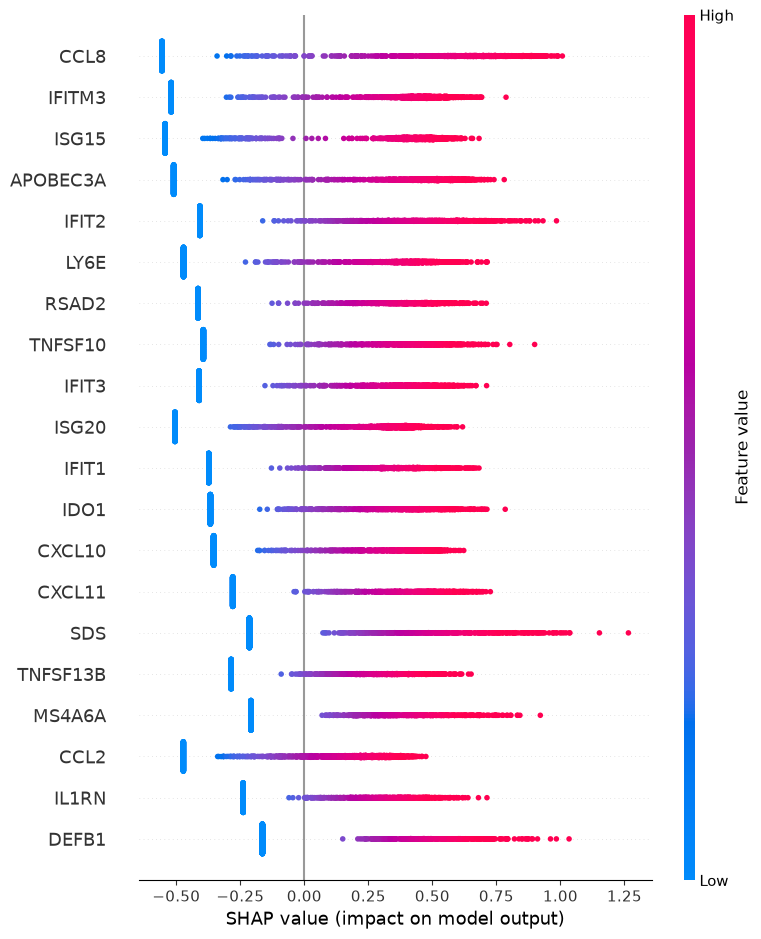

In [8]:
# visualize SHAP values for top genes

shap.summary_plot(shap_values, X_test, feature_names=[gene_id_to_symbol.get(g, g) for g in gene_names], max_display=20)

In [9]:
# run SHAP across all cell types and save results

all_top_genes = {}

for ct in cell_types:
    clf = results[ct]["clf"]
    X_test = results[ct]["X_test"]
    gene_names = results[ct]["gene_names"]

    explainer = shap.LinearExplainer(clf, X_test)
    shap_values = explainer.shap_values(X_test)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:10]

    top_genes = pd.DataFrame({
        "gene_symbol": [gene_id_to_symbol.get(gene_names[i], gene_names[i]) for i in top_idx],
        "mean_abs_shap": mean_abs_shap[top_idx]
    })

    all_top_genes[ct] = top_genes
    print(f"\n{ct}:")
    print(top_genes["gene_symbol"].tolist())


CD4 T cells:
['ISG15', 'IFIT3', 'IFIT1', 'LY6E', 'ISG20', 'MT2A', 'OAS1', 'IFIT2', 'SAT1', 'IRF7']

CD14+ Monocytes:
['CCL8', 'IFITM3', 'ISG15', 'APOBEC3A', 'IFIT2', 'LY6E', 'RSAD2', 'TNFSF10', 'IFIT3', 'ISG20']

Dendritic cells:
['CKB', 'CCL22', 'IRF8', 'TSPAN13', 'CD38', 'CLIC2', 'ALDH2', 'ISG15', 'PKIB', 'PDGFRL']

NK cells:
['IFIT1', 'IFIT3', 'ISG20', 'ISG15', 'PRF1', 'LY6E', 'OAS1', 'IRF7', 'CD38', 'FGFBP2']

CD8 T cells:
['ISG15', 'LAG3', 'ISG20', 'IFIT1', 'LY6E', 'IFIT3', 'MT2A', 'OAS1', 'FGFBP2', 'IRF7']

B cells:
['IFIT3', 'ISG15', 'ISG20', 'IFIT1', 'LY6E', 'IFIT2', 'IRF7', 'IRF8', 'CXCL10', 'GBP1']

Megakaryocytes:
['GNG11', 'MYL9', 'ISG15', 'LY6E', 'IFIT3', 'IFIT1', 'ISG20', 'PGRMC1', 'C2orf88', 'NGFRAP1']

FCGR3A+ Monocytes:
['IFIT1', 'ISG15', 'CXCL11', 'IFIT2', 'ISG20', 'IFIT3', 'LY6E', 'APOBEC3A', 'CXCL10', 'TNFSF10']


In [10]:
from collections import Counter

all_symbols = []
for ct, df in all_top_genes.items():
    all_symbols.extend(df["gene_symbol"].tolist())

gene_counts = Counter(all_symbols)
consensus = pd.DataFrame(gene_counts.most_common(20), columns=["gene_symbol", "n_cell_types"])
print(consensus)

   gene_symbol  n_cell_types
0        ISG15             8
1        IFIT3             7
2         LY6E             7
3        ISG20             7
4        IFIT1             6
5        IFIT2             4
6         IRF7             4
7         OAS1             3
8         MT2A             2
9     APOBEC3A             2
10     TNFSF10             2
11        IRF8             2
12        CD38             2
13      FGFBP2             2
14      CXCL10             2
15        SAT1             1
16        CCL8             1
17      IFITM3             1
18       RSAD2             1
19         CKB             1


In [11]:
consensus.to_csv(ROOT / "results" / "consensus_biomarkers.csv", index=False)

for ct, df in all_top_genes.items():
    fname = ct.replace("+", "pos").replace(" ", "_")
    df.to_csv(ROOT / "results" / f"top_genes_{fname}.csv", index=False)

print("SHAP analysis complete! Results saved to 'results' directory.")

SHAP analysis complete! Results saved to 'results' directory.
